# Benchmark Results Visualization

In [5]:
from pathlib import Path
import sys

from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'benchmark').exists() and (REPO_ROOT.parent / 'benchmark').exists():
    REPO_ROOT = REPO_ROOT.parent.resolve()

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from analysis.benchmark_visualizations import (
    best_model_ids,
    load_benchmark_frames,
    plot_accuracy_latency_tradeoff,
    plot_accuracy_token_tradeoff,
    plot_common_confusions,
    plot_confusion_matrix,
    plot_cost_accuracy_tradeoff,
    plot_error_rates,
    plot_hardest_tools,
    plot_heatmap_by_variant,
    plot_hybrid_lift,
    plot_latency_distribution,
    plot_metric_by_provider,
    plot_metric_triptych,
    plot_per_tool_heatmap,
    plot_top_metric_bars,
    save_figure,
    set_plot_style,
    top_model_table,
)

set_plot_style()

In [6]:
BENCHMARK_RUN = 'oss-full-benchmark'
SUMMARY_PATH = REPO_ROOT / 'benchmark' / 'output' / BENCHMARK_RUN / 'summary.json'
RESULTS_DIR = SUMMARY_PATH.parent / 'results'
FIGURES_DIR = REPO_ROOT / 'analysis' / 'figures' / BENCHMARK_RUN

frames = load_benchmark_frames(SUMMARY_PATH, results_dir=RESULTS_DIR)
summary = frames['summary']
models_df = frames['models']
ok_models_df = frames['successful_models']
results_df = frames['results']
ok_results_df = frames['successful_results']

print('Benchmark:', summary['benchmark'])
print('Model count:', len(models_df))
print('Successful models:', len(ok_models_df))
print('Example rows:', len(results_df))
print('Results dir:', RESULTS_DIR)
print('Figures dir:', FIGURES_DIR)

Benchmark: tool_selection
Model count: 24
Successful models: 21
Example rows: 2184
Results dir: /scratch4/home/akrik/NTILC/benchmark/output/oss-full-benchmark/results
Figures dir: /scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark


In [7]:
overview_columns = [
    'display_name',
    'provider_label',
    'mode',
    'top_1_accuracy',
    'top_3_accuracy',
    'top_5_accuracy',
    'mean_reciprocal_rank',
    'mean_latency_ms',
    'mean_total_tokens',
    'sum_cost_usd',
    'error_rate',
]
display(top_model_table(ok_models_df, top_n=15)[overview_columns[:-1]])
display(models_df[['display_name', 'provider_label', 'mode', 'status', 'error_rate']].sort_values(['status', 'error_rate', 'display_name']))

,display_name,provider_label,mode,top_1_accuracy,top_3_accuracy,top_5_accuracy,mean_reciprocal_rank,mean_latency_ms,mean_total_tokens,sum_cost_usd
0,normal/circle,Embedding,embedding,0.942308,1.000000,1.000000,0.969551,2.658082,16.826923,0.0
1,normal/contrastive,Embedding,embedding,0.942308,0.990385,1.000000,0.967147,2.645478,16.826923,0.0
2,normal/functional_margin + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.942308,1.000000,1.000000,0.971154,8026.817207,397.663462,0.0
3,normal/contrastive + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.942308,1.000000,1.000000,0.971154,6915.220812,397.548077,0.0
4,hierarchical/contrastive + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.942308,0.990385,0.990385,0.966346,5443.562232,394.144231,0.0
5,hierarchical/prototype_ce + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.942308,1.000000,1.000000,0.971154,5377.140807,397.932692,0.0
6,normal/circle + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.942308,1.000000,1.000000,0.971154,7773.173284,397.250000,0.0
7,normal/prototype_ce + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.932692,1.000000,1.000000,0.966346,6547.782114,397.625000,0.0
8,hierarchical/functional_margin + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.932692,1.000000,1.000000,0.966346,7749.477162,397.807692,0.0
9,hierarchical/circle + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,0.932692,0.980769,0.980769,0.956731,7402.040896,394.173077,0.0


,display_name,provider_label,mode,status,error_rate
22,claude-opus-4-1-20250805,Anthropic,llm_api,error,0.0
23,gemini-2.5-pro,Gemini,llm_api,error,0.0
21,gpt-5.2,OpenAI,llm_api,error,0.0
16,Qwen/Qwen3.5-4B,Local OSS LLM,llm_local,ok,0.0
17,Qwen/Qwen3.5-9B,Local OSS LLM,llm_local,ok,0.0
0,hierarchical/circle,Embedding,embedding,ok,0.0
8,hierarchical/circle + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,ok,0.0
1,hierarchical/contrastive,Embedding,embedding,ok,0.0
9,hierarchical/contrastive + Qwen/Qwen3.5-27B,Hybrid,embedding_rerank,ok,0.0
2,hierarchical/functional_margin,Embedding,embedding,ok,0.0


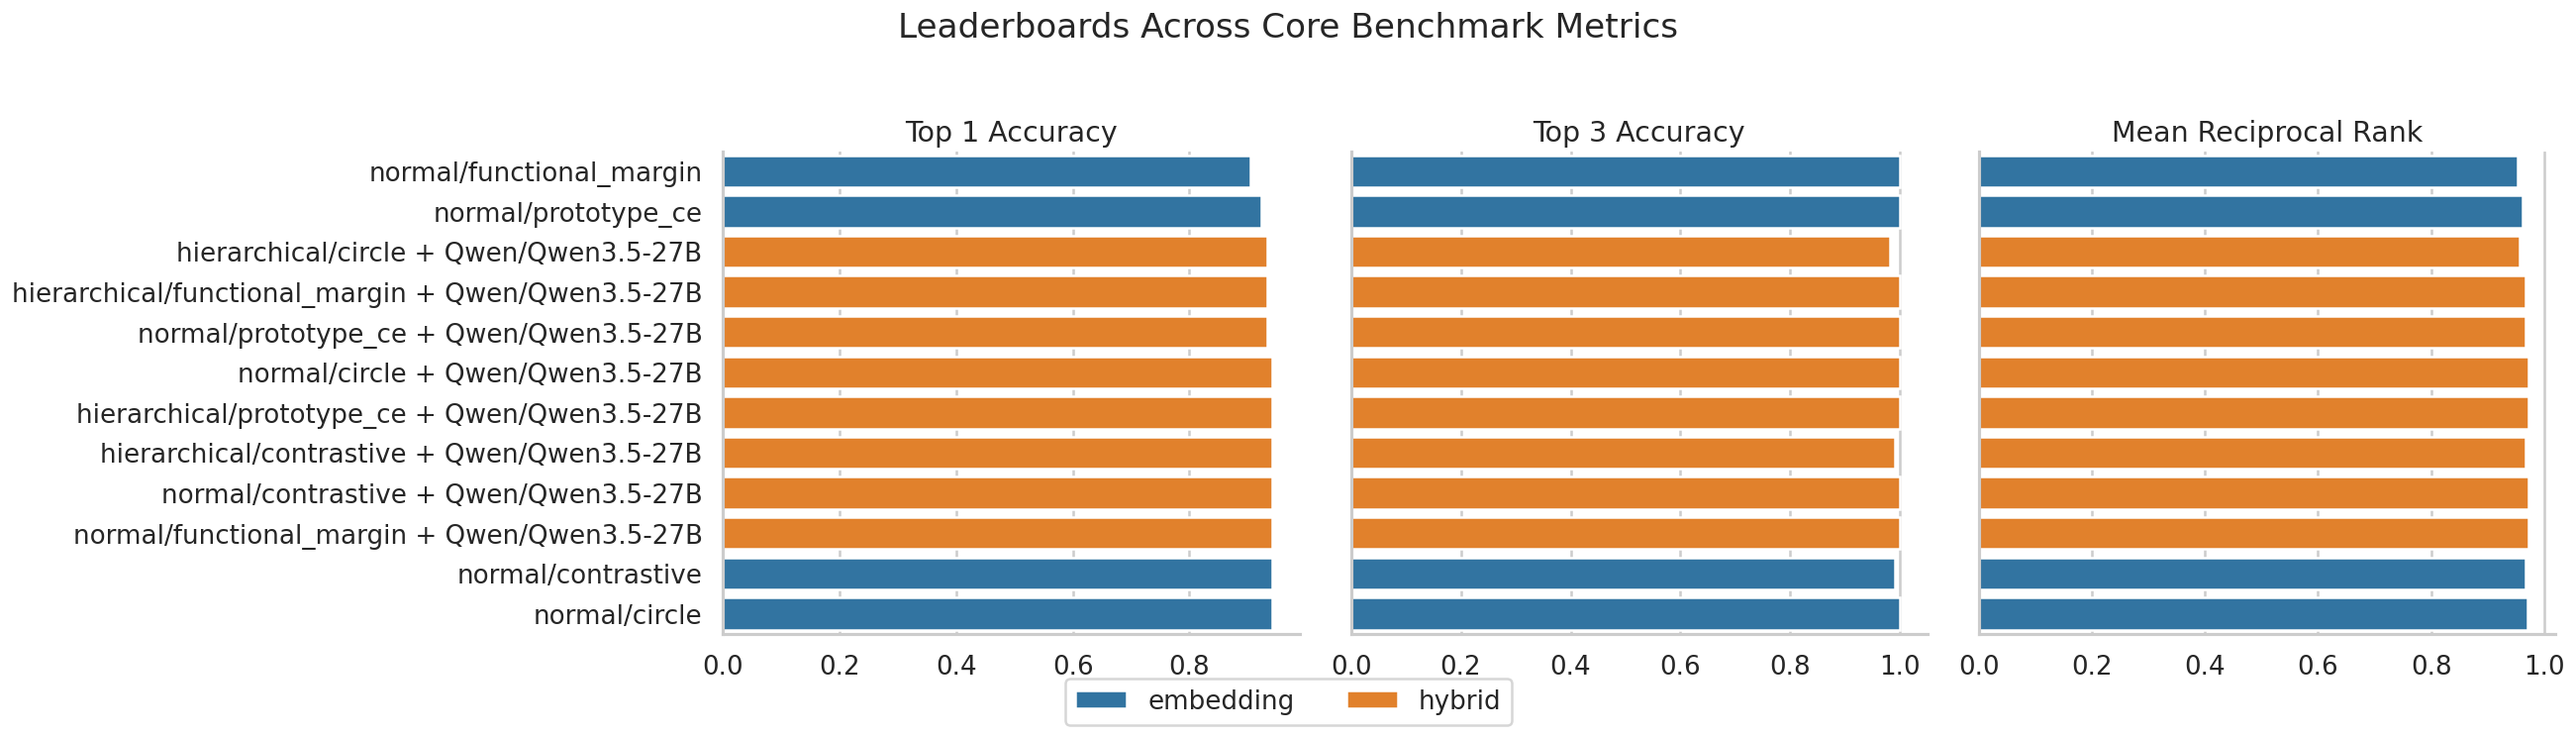

In [8]:
FIGURES = {}

FIGURES['leaderboard_triptych'], _ = plot_metric_triptych(ok_models_df, top_n=12)

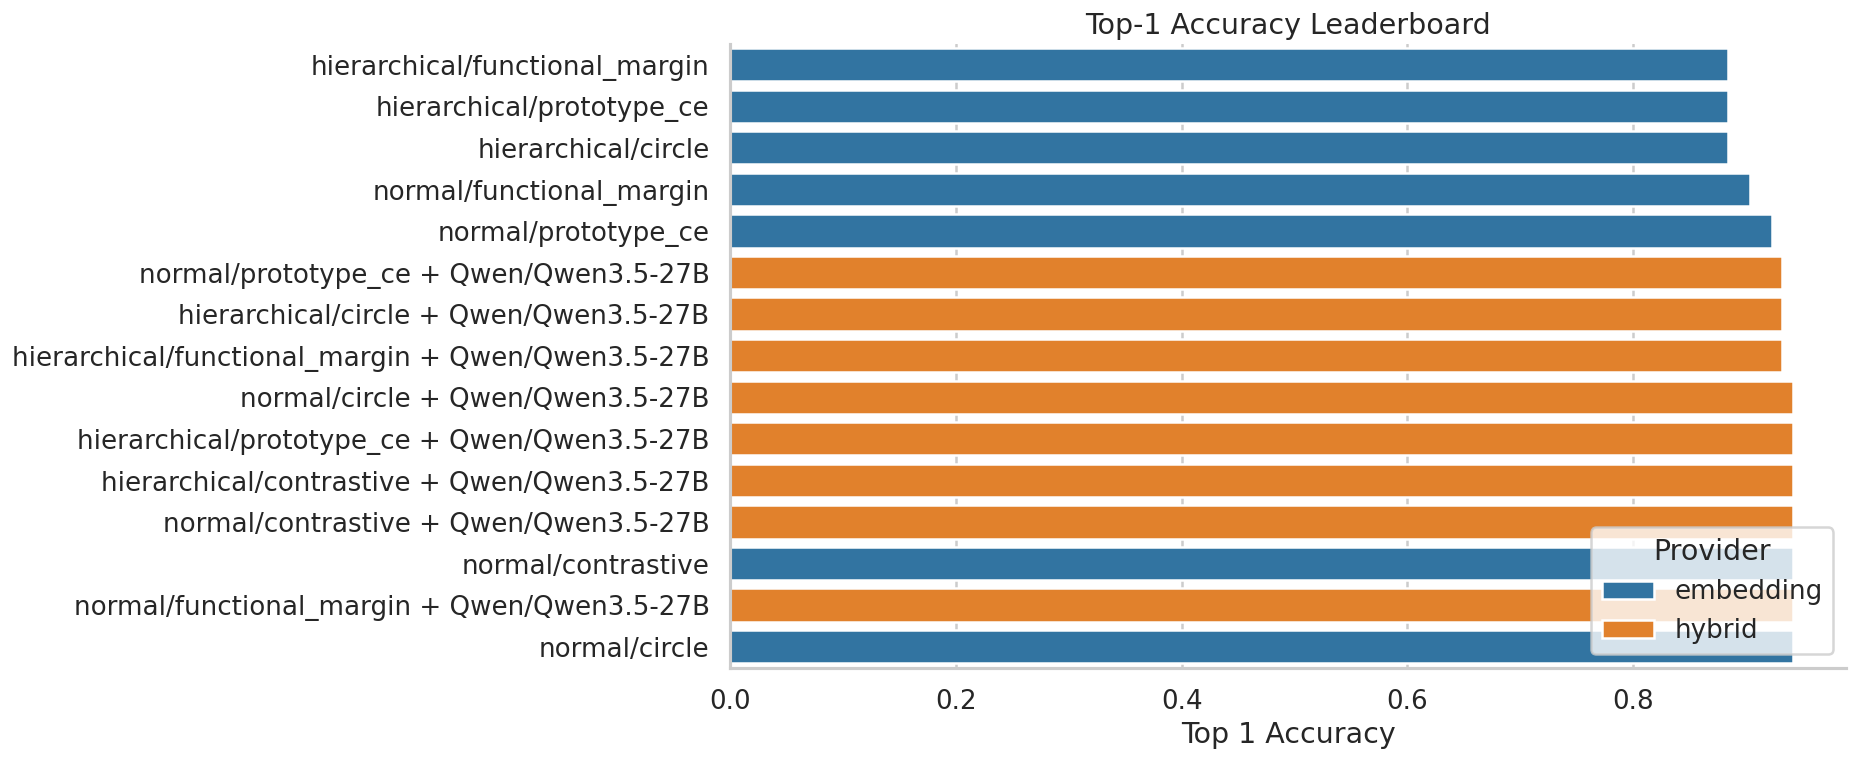

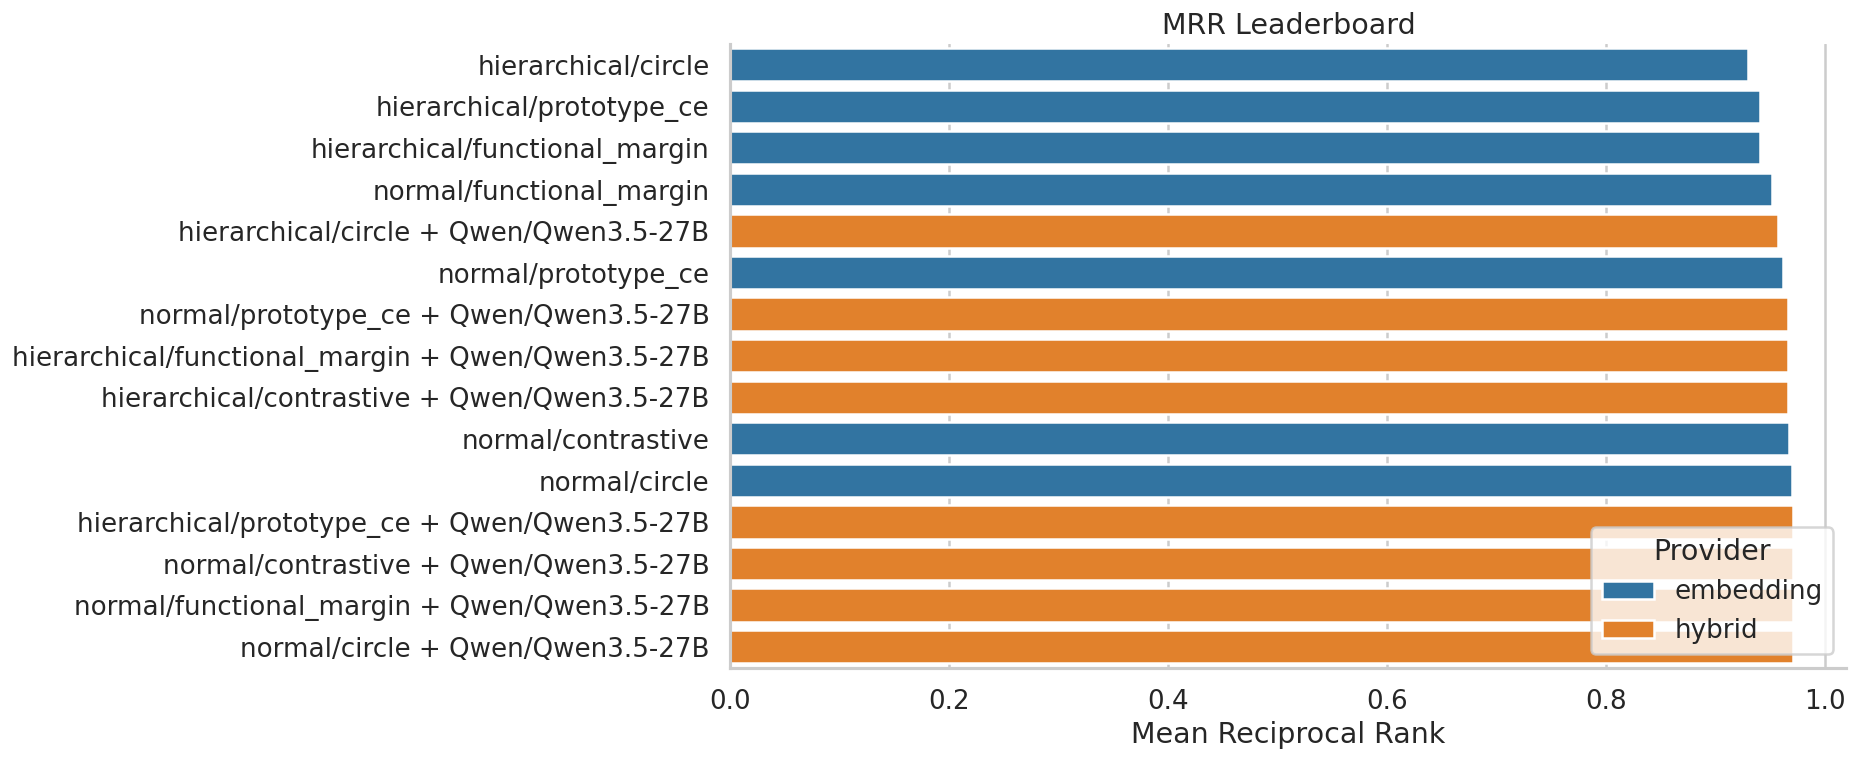

In [9]:
FIGURES['top1_leaderboard'], _ = plot_top_metric_bars(
    ok_models_df,
    metric='top_1_accuracy',
    top_n=15,
    title='Top-1 Accuracy Leaderboard',
)
FIGURES['top1_leaderboard'].show()

FIGURES['mrr_leaderboard'], _ = plot_top_metric_bars(
    ok_models_df,
    metric='mean_reciprocal_rank',
    top_n=15,
    title='MRR Leaderboard',
)
FIGURES['mrr_leaderboard'].show()

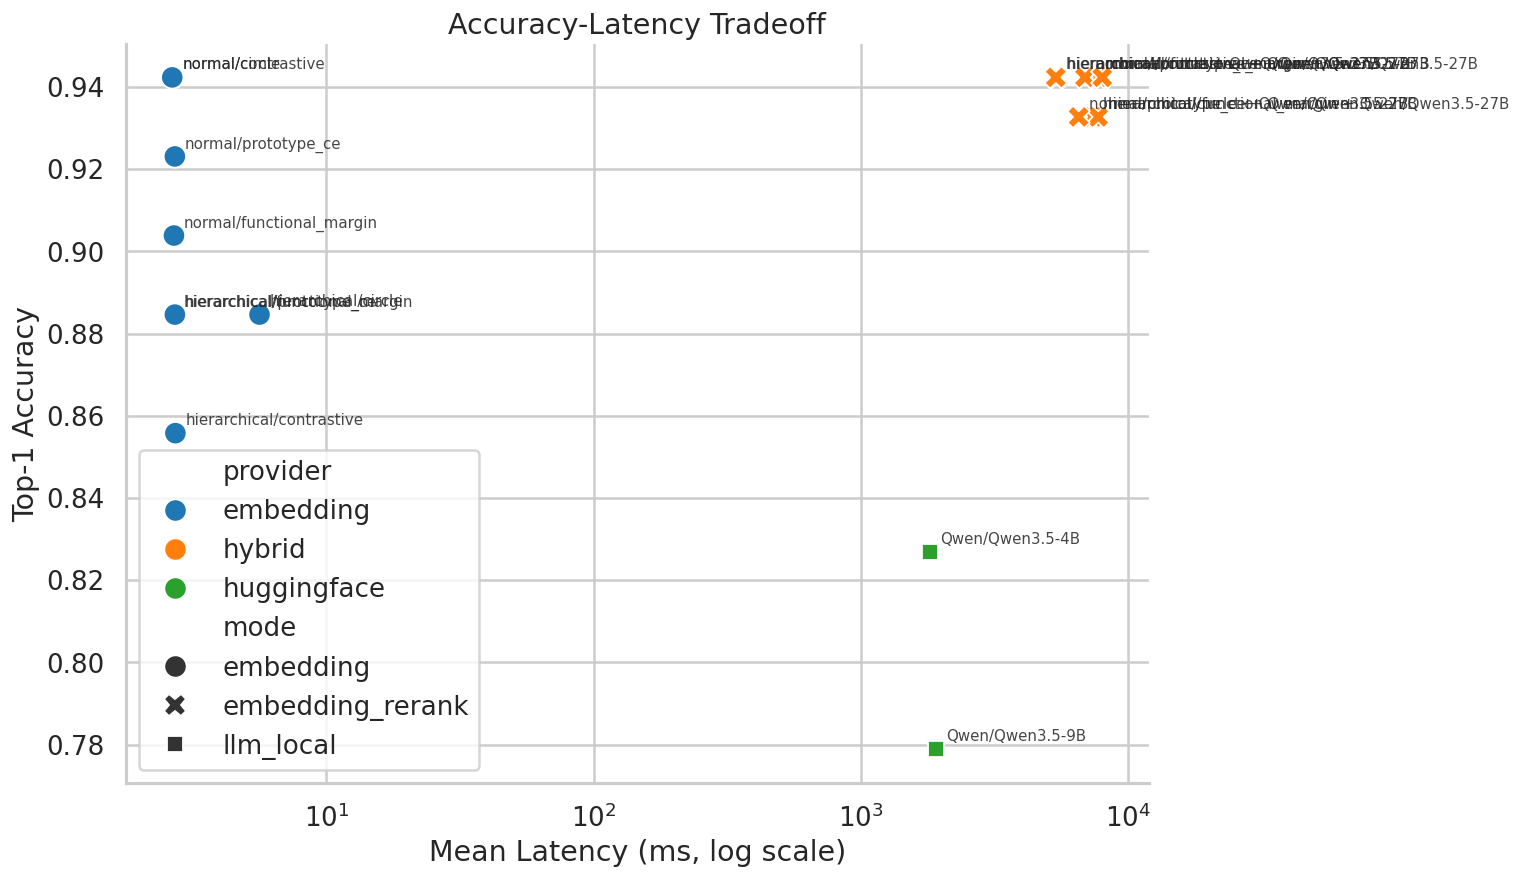

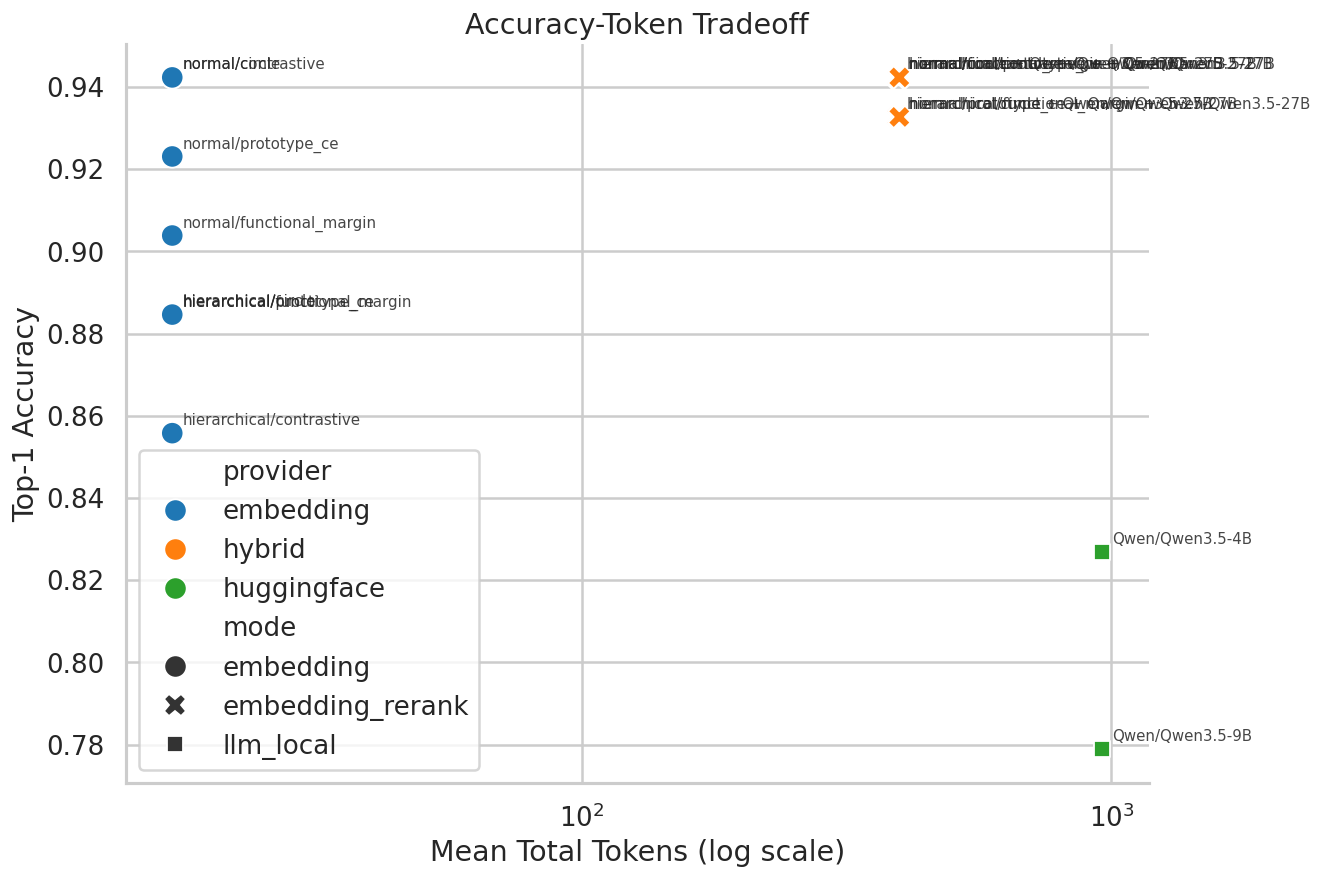

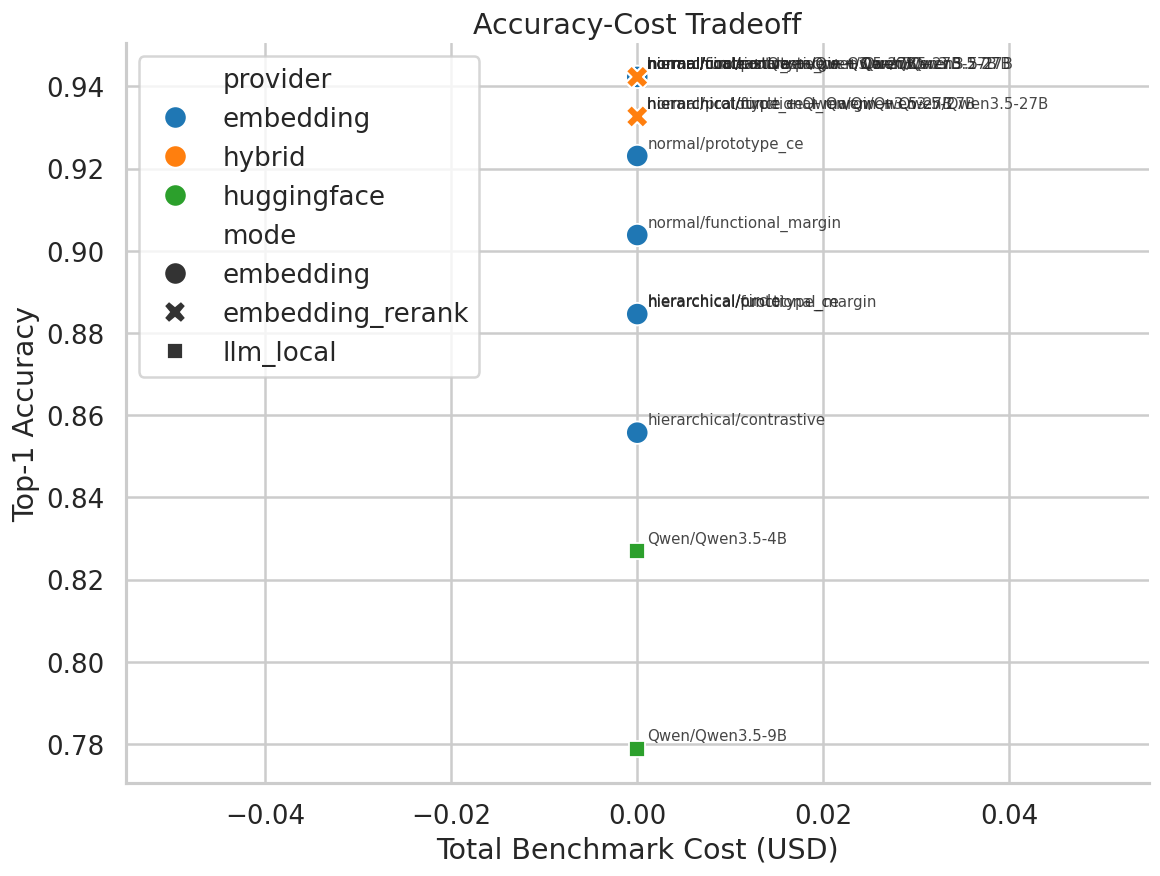

In [10]:
FIGURES['accuracy_latency_tradeoff'], _ = plot_accuracy_latency_tradeoff(ok_models_df)
FIGURES['accuracy_token_tradeoff'], _ = plot_accuracy_token_tradeoff(ok_models_df)
FIGURES['cost_accuracy_tradeoff'], _ = plot_cost_accuracy_tradeoff(ok_models_df)

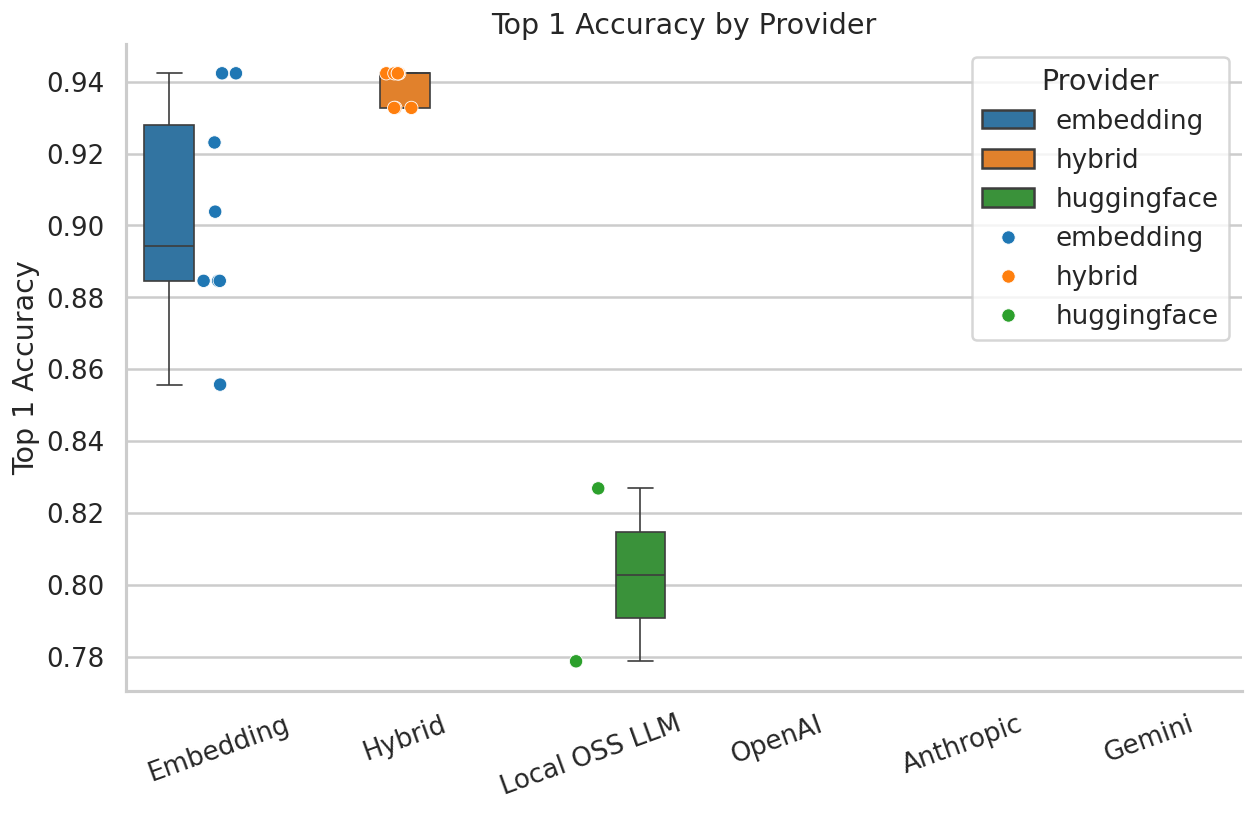

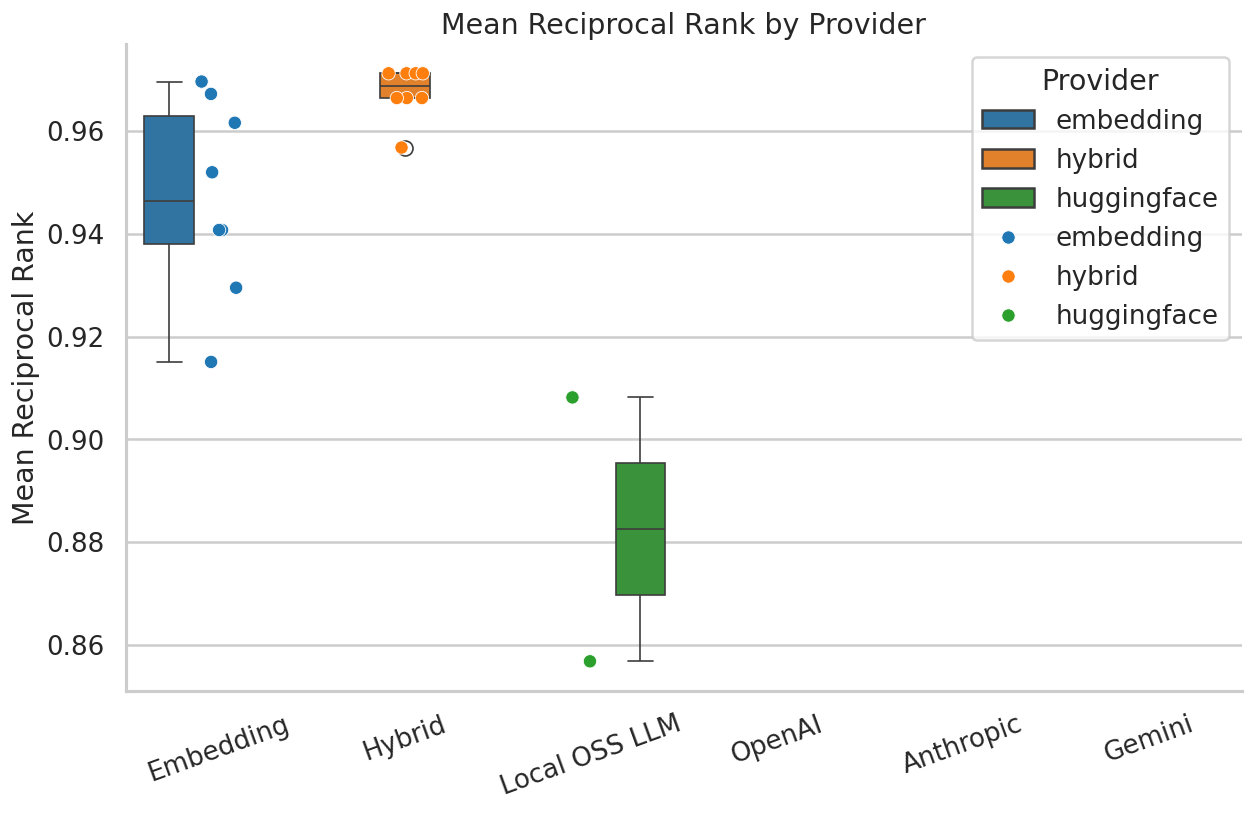

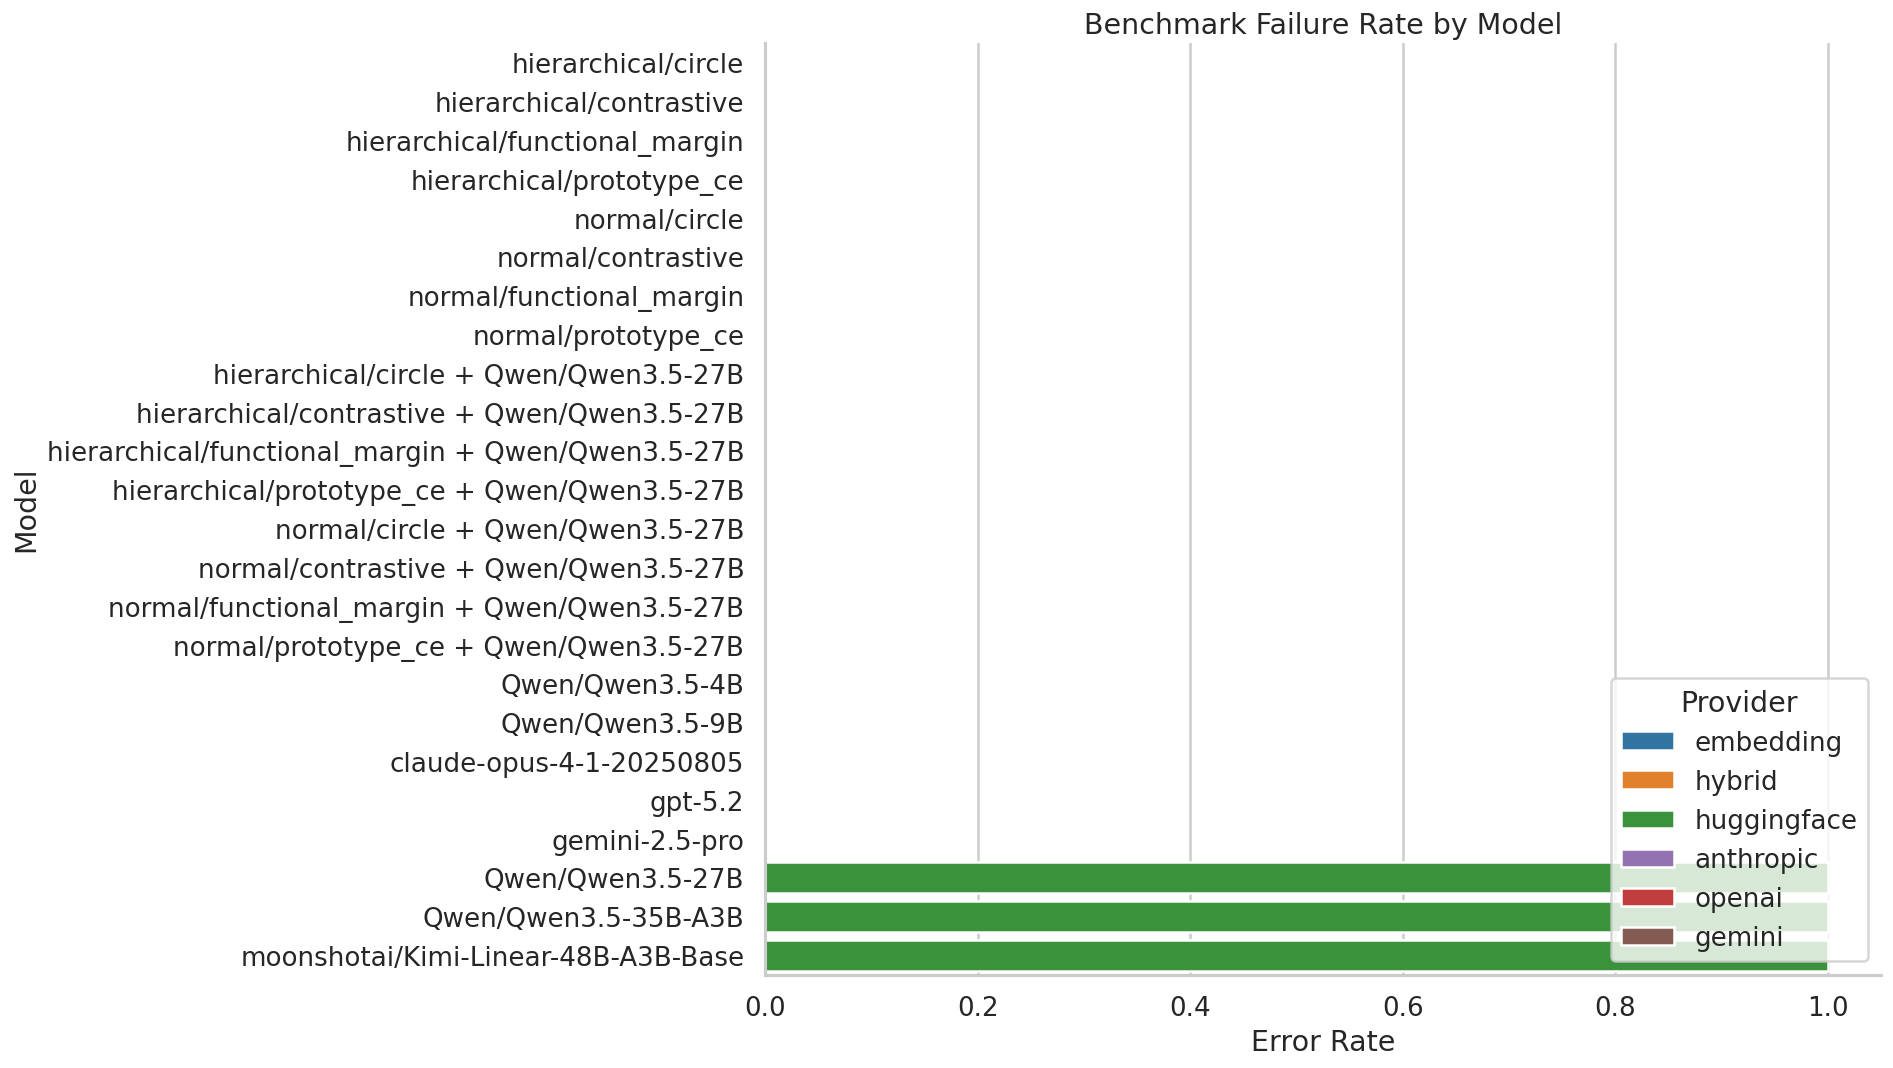

In [11]:
FIGURES['provider_top1_boxplot'], _ = plot_metric_by_provider(ok_models_df, metric='top_1_accuracy')
FIGURES['provider_mrr_boxplot'], _ = plot_metric_by_provider(ok_models_df, metric='mean_reciprocal_rank')
FIGURES['error_rates'], _ = plot_error_rates(models_df)

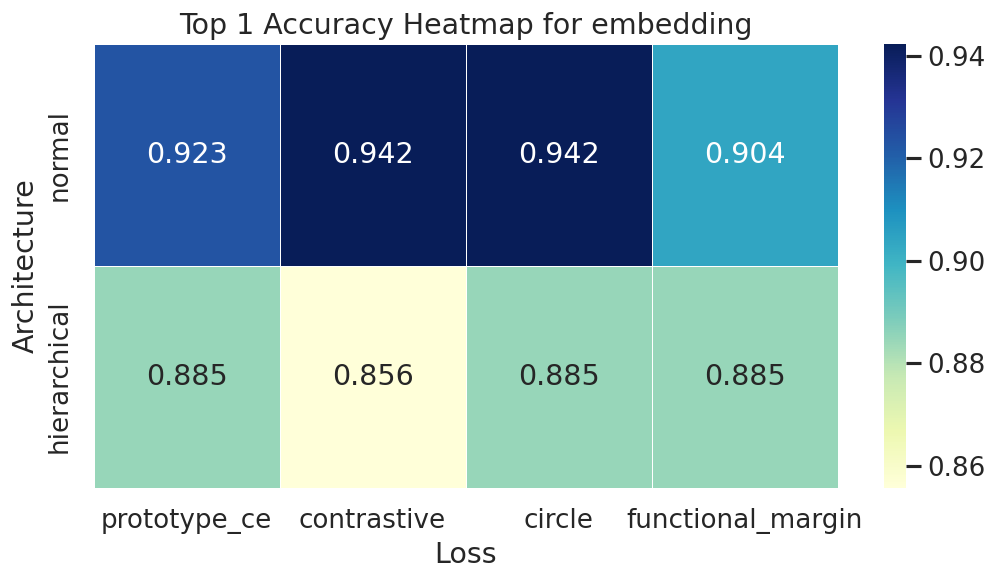

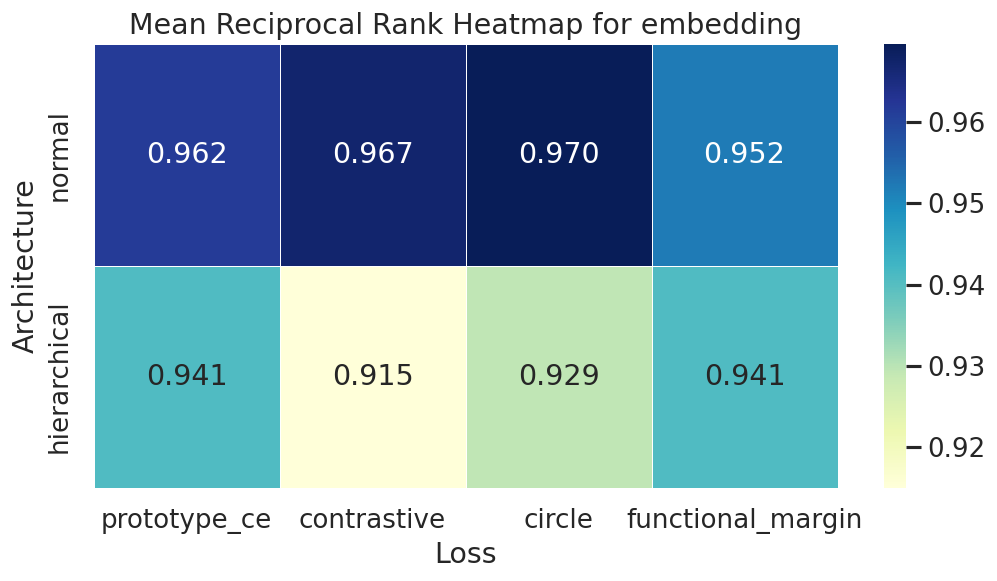

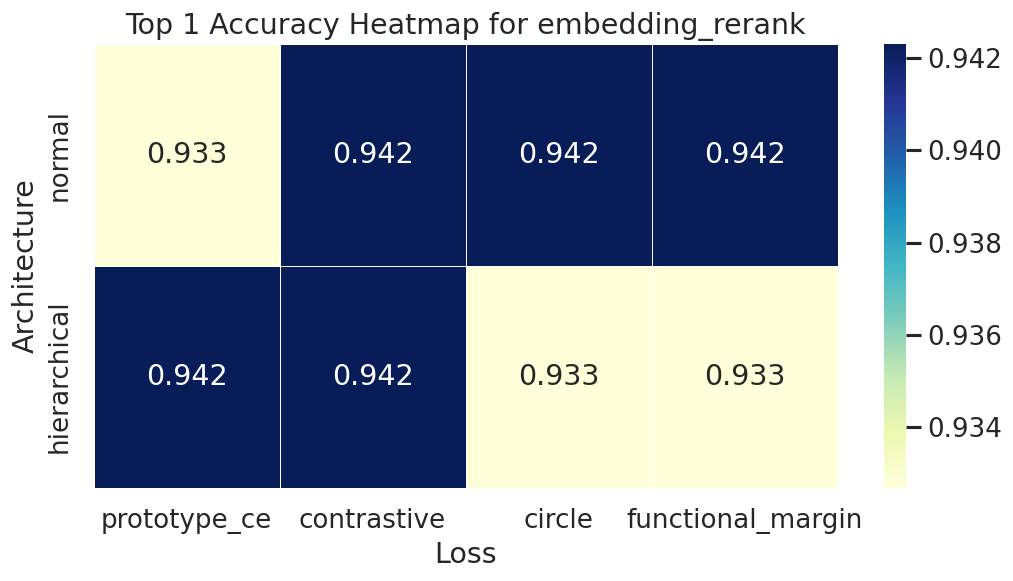

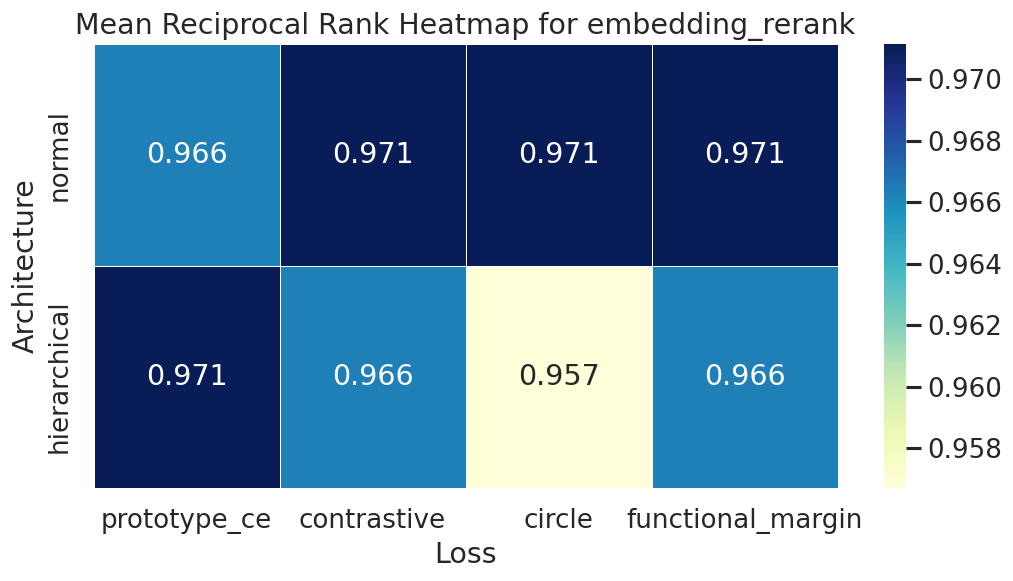

In [12]:
FIGURES['embedding_top1_heatmap'], _ = plot_heatmap_by_variant(ok_models_df, mode='embedding', metric='top_1_accuracy')
FIGURES['embedding_mrr_heatmap'], _ = plot_heatmap_by_variant(ok_models_df, mode='embedding', metric='mean_reciprocal_rank')
FIGURES['hybrid_top1_heatmap'], _ = plot_heatmap_by_variant(ok_models_df, mode='embedding_rerank', metric='top_1_accuracy')
FIGURES['hybrid_mrr_heatmap'], _ = plot_heatmap_by_variant(ok_models_df, mode='embedding_rerank', metric='mean_reciprocal_rank')

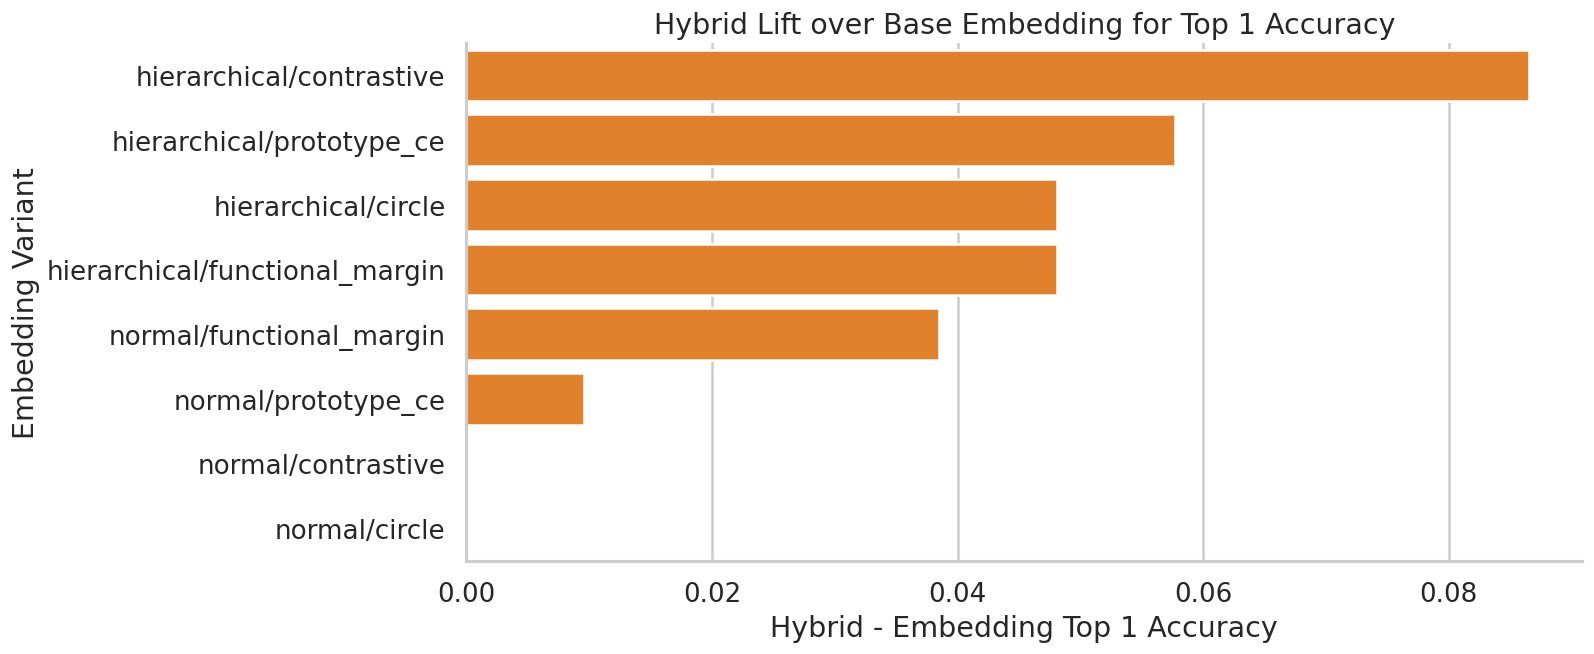

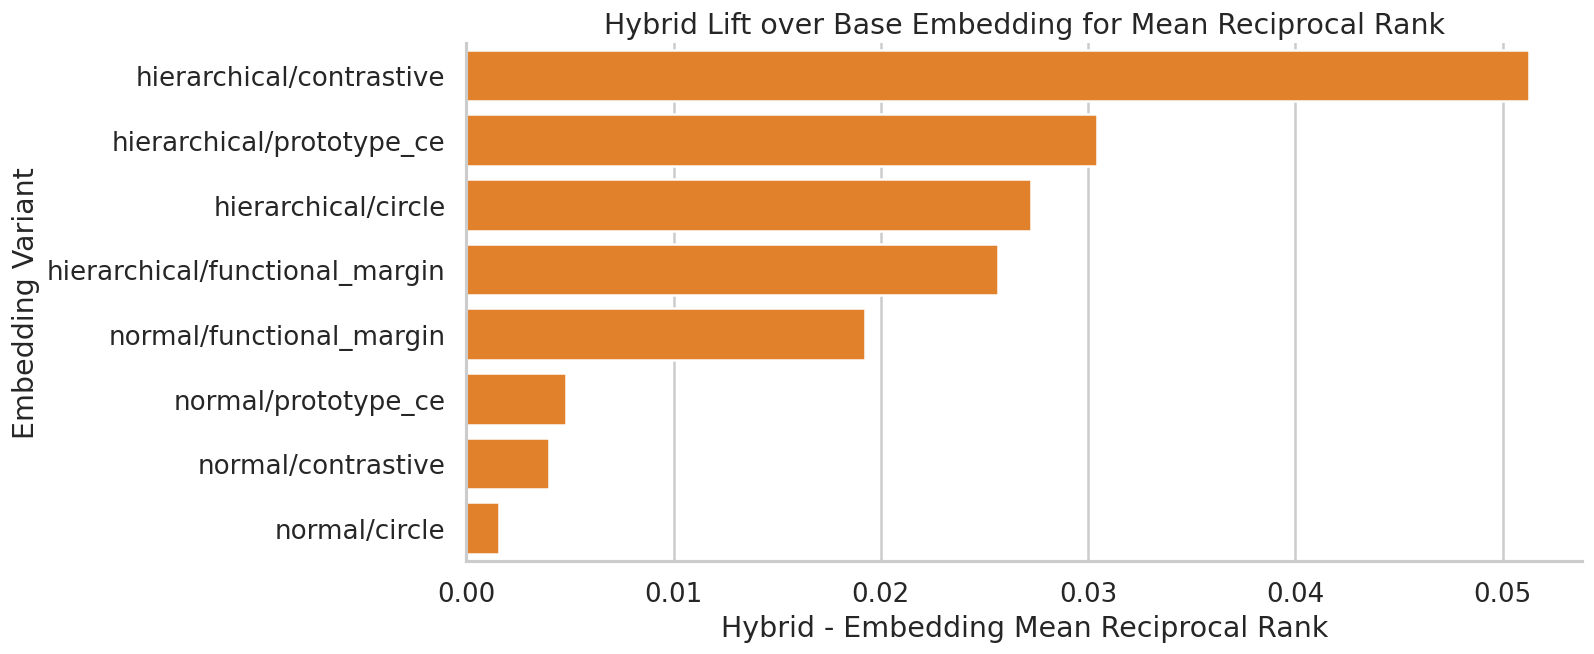

In [13]:
FIGURES['hybrid_lift_top1'], _ = plot_hybrid_lift(ok_models_df, metric='top_1_accuracy')
FIGURES['hybrid_lift_mrr'], _ = plot_hybrid_lift(ok_models_df, metric='mean_reciprocal_rank')

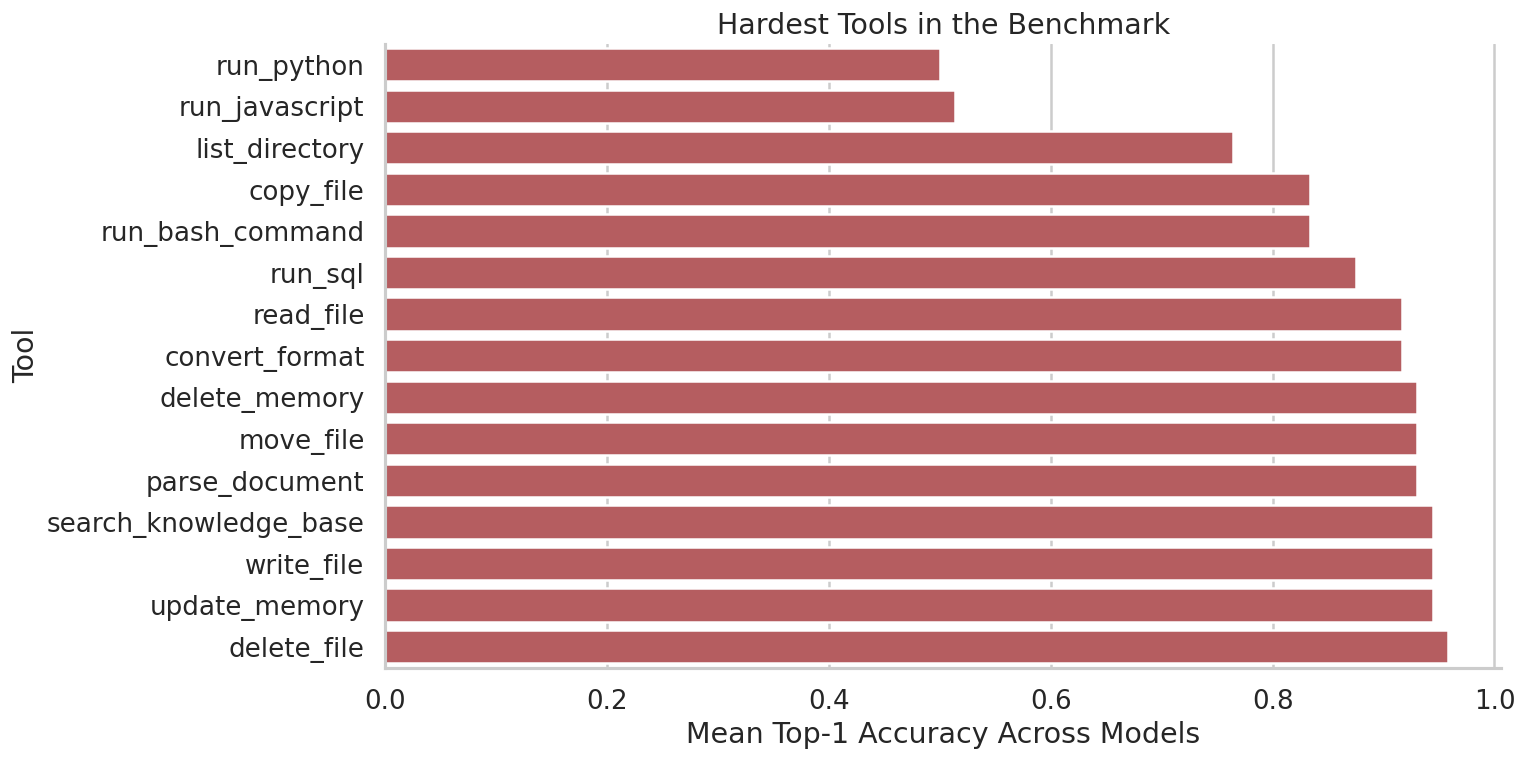

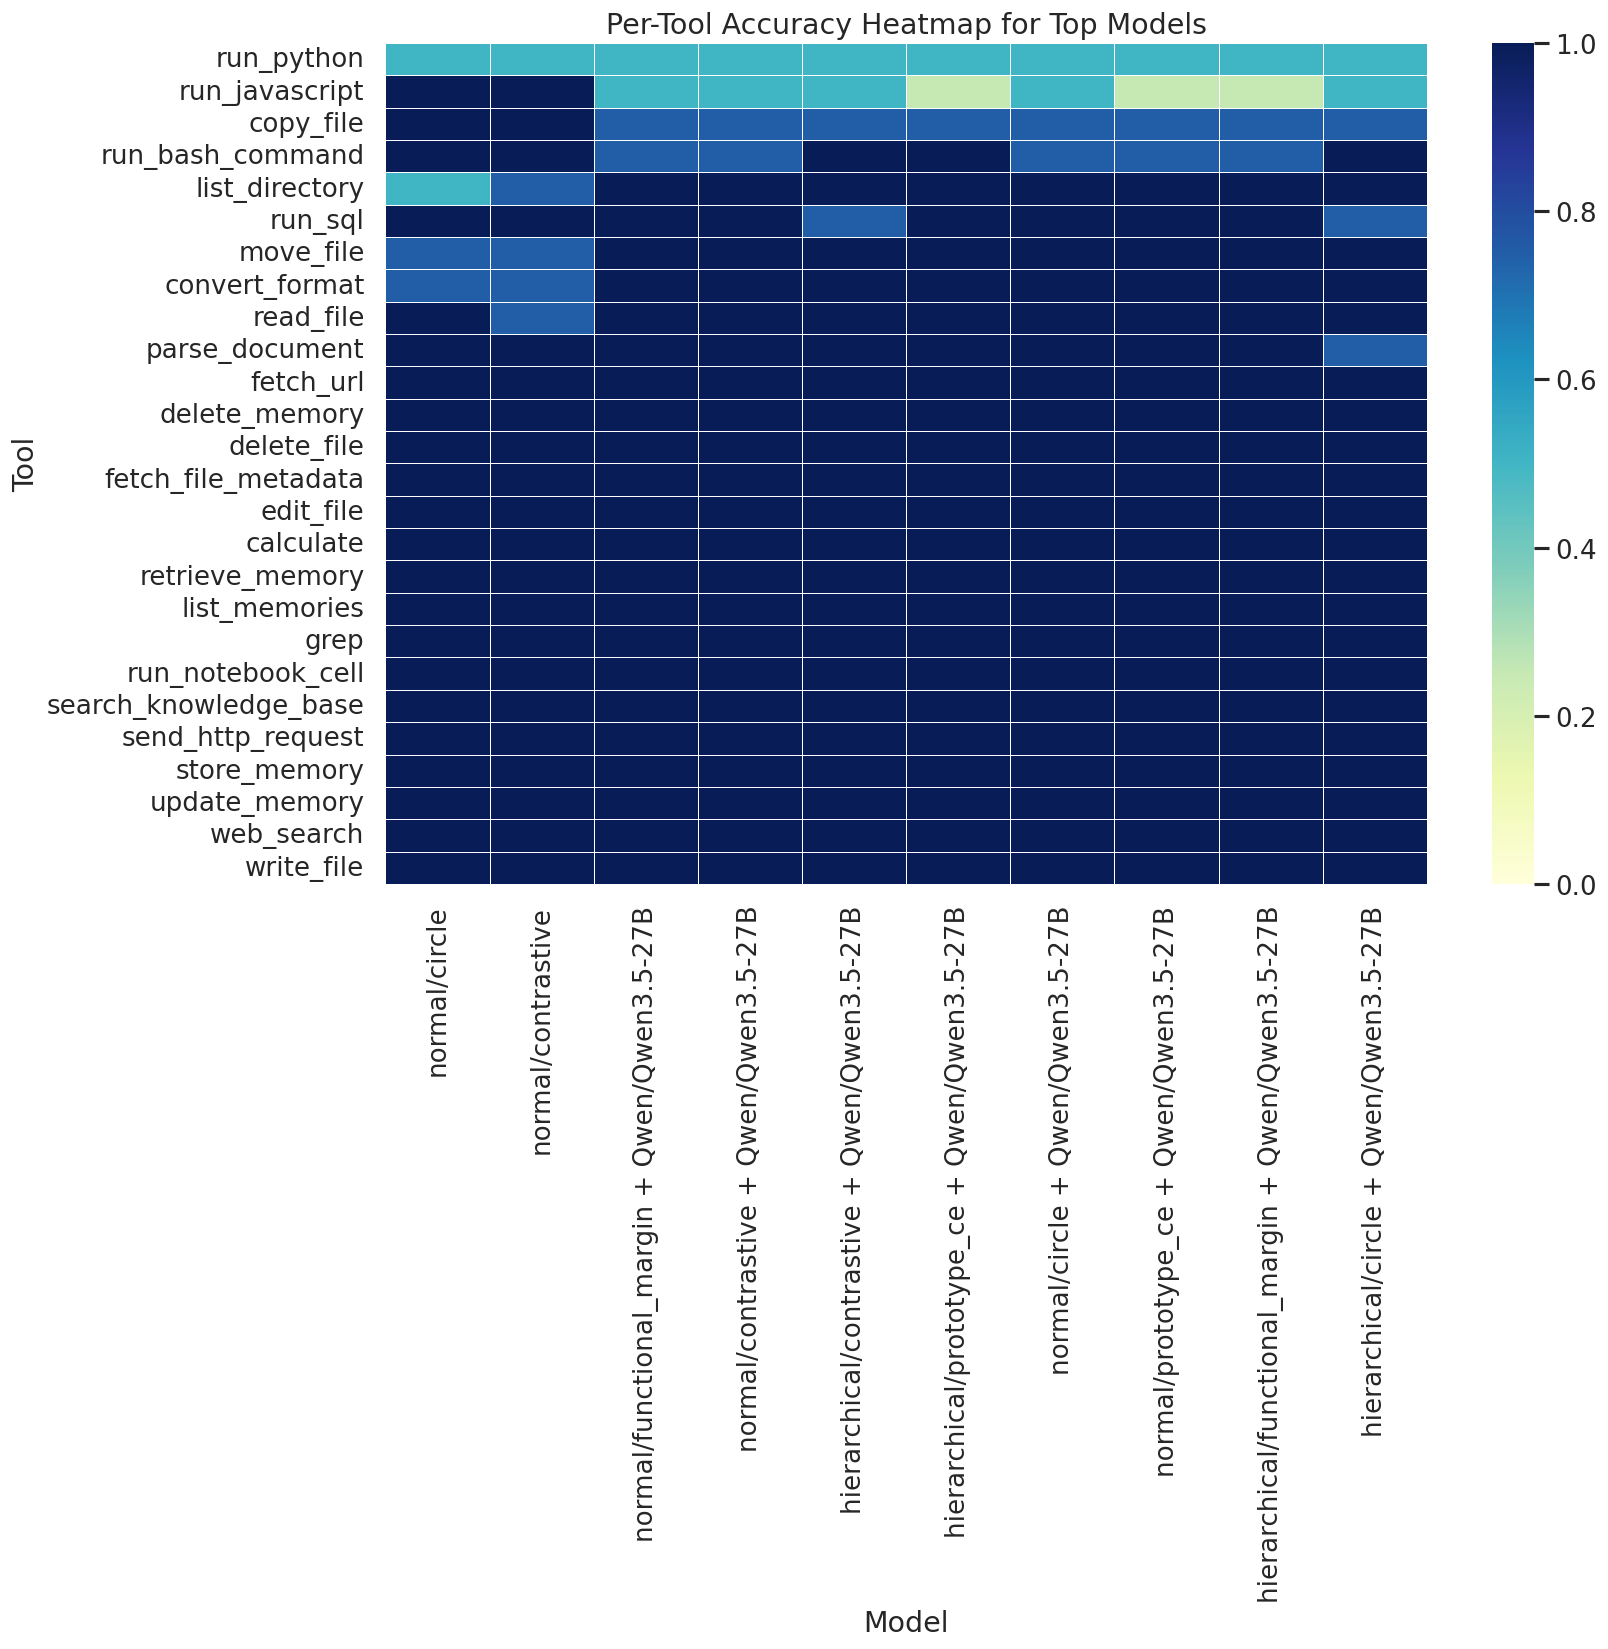

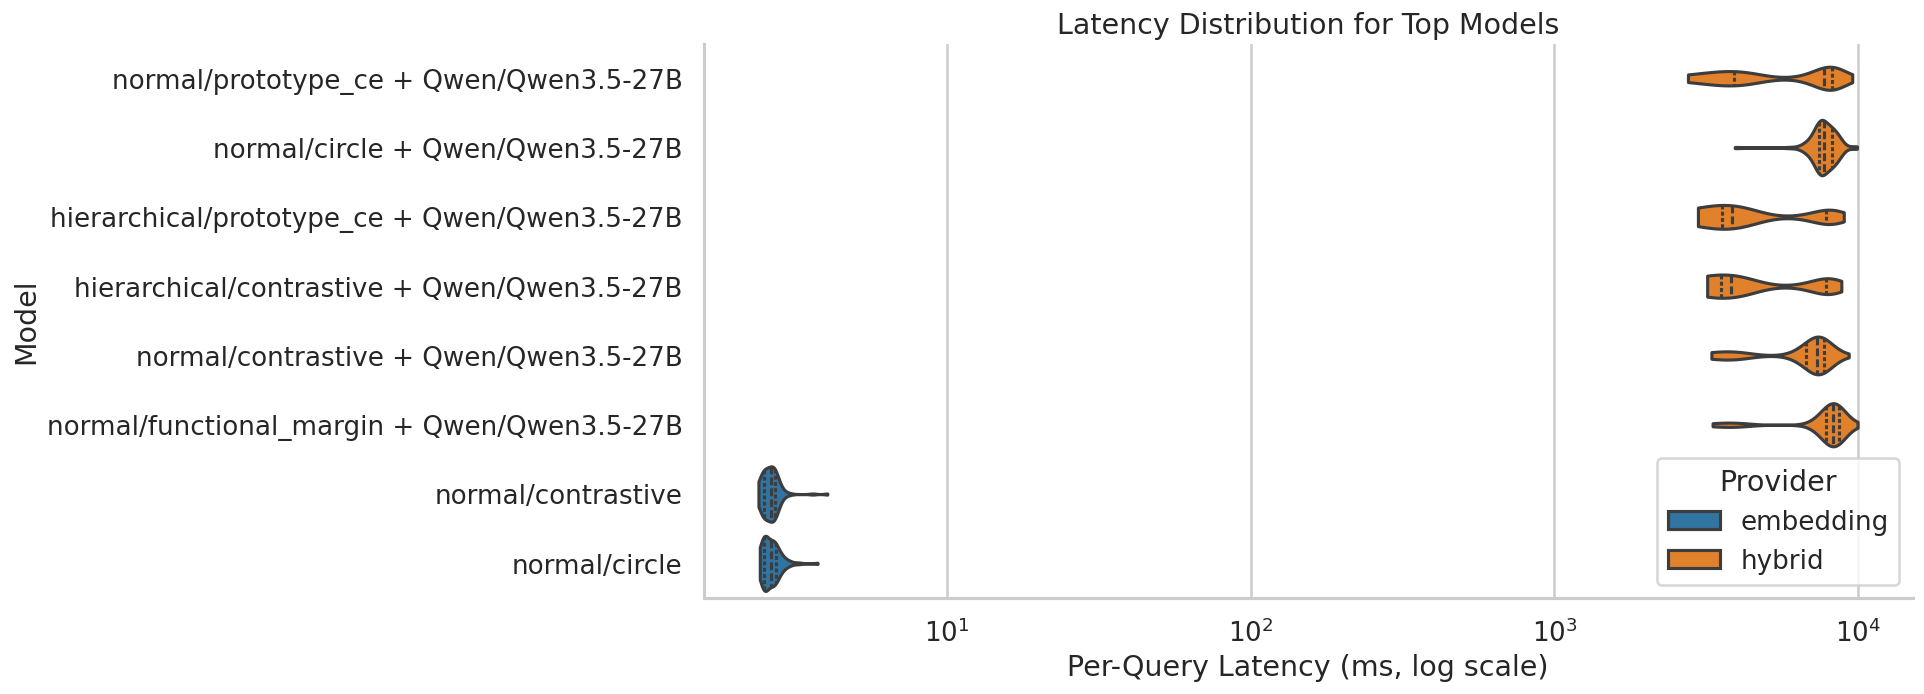

In [14]:
FIGURES['hardest_tools'], _ = plot_hardest_tools(ok_results_df, top_n=15)
FIGURES['per_tool_heatmap'], _ = plot_per_tool_heatmap(ok_results_df, ok_models_df, top_n_models=10)
FIGURES['latency_distribution'], _ = plot_latency_distribution(ok_results_df, ok_models_df, top_n_models=8)

In [15]:
best_overall_adapter = best_model_ids(ok_models_df, top_n=1)[0]
best_embedding_adapter = (
    ok_models_df.loc[ok_models_df['provider'] == 'embedding']
    .sort_values('top_1_accuracy', ascending=False)
    .iloc[0]['adapter_id']
)

print('Best overall adapter:', best_overall_adapter)
print('Best embedding adapter:', best_embedding_adapter)

Best overall adapter: embedding/normal-circle
Best embedding adapter: embedding/normal-contrastive


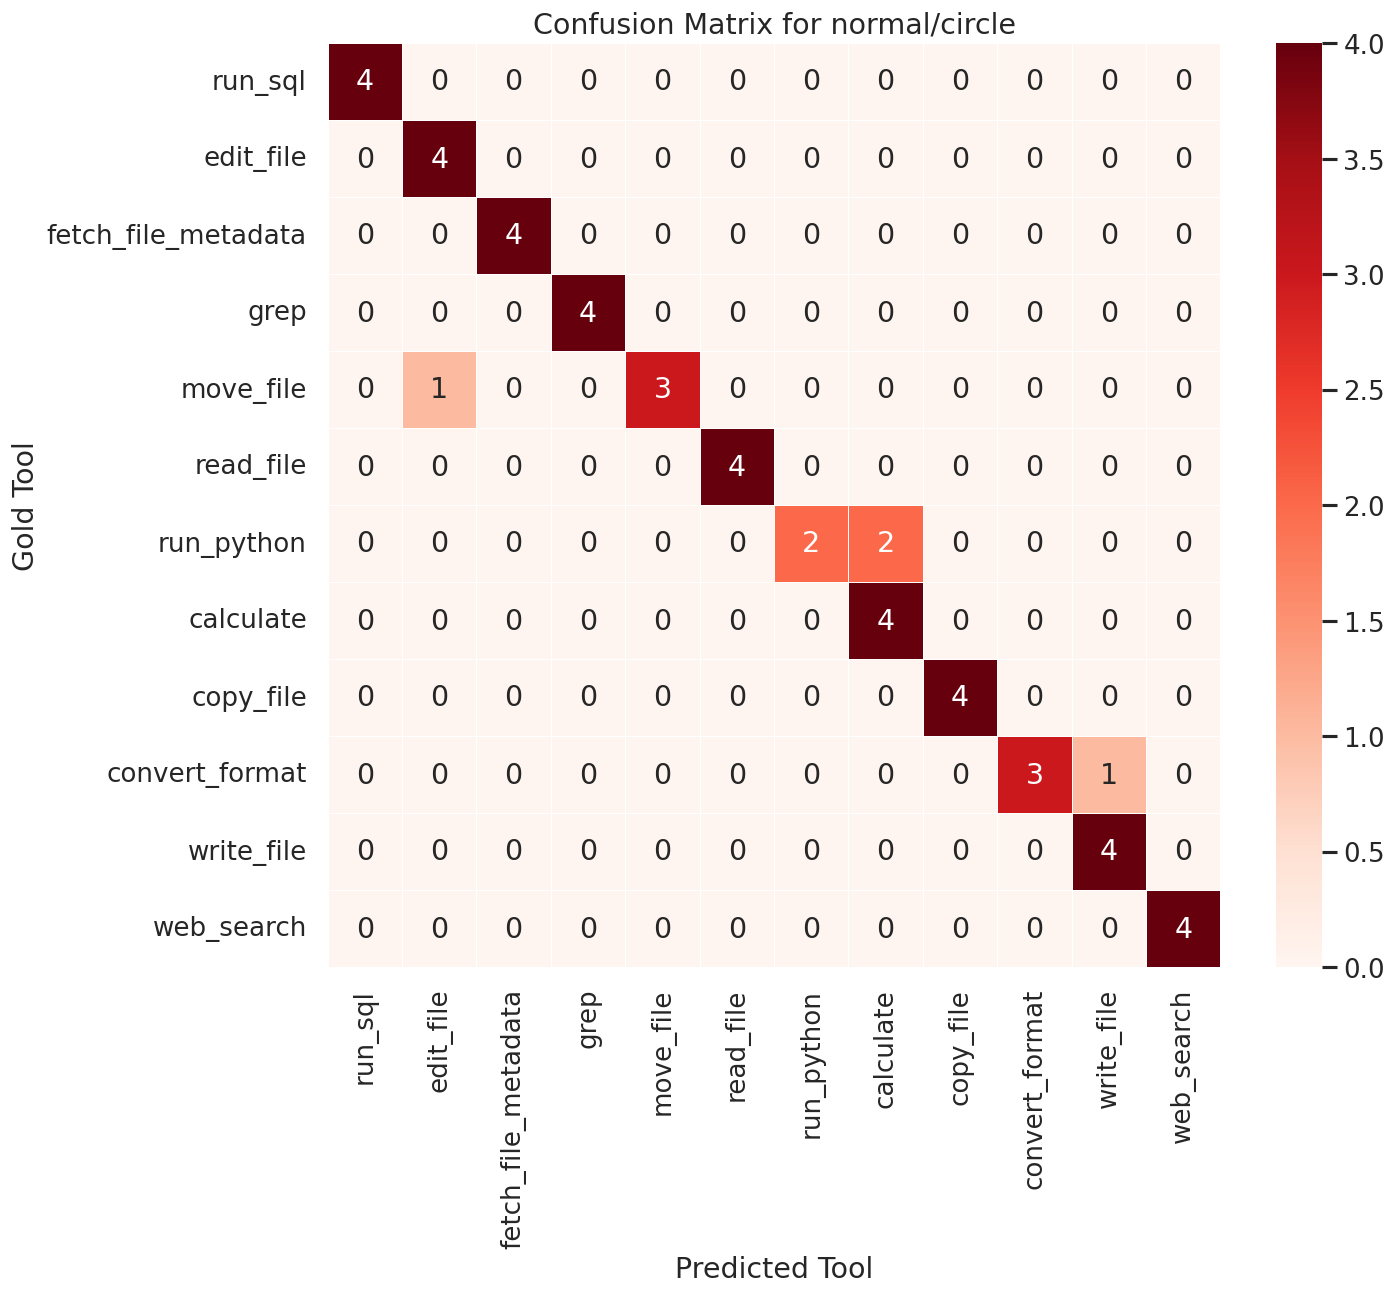

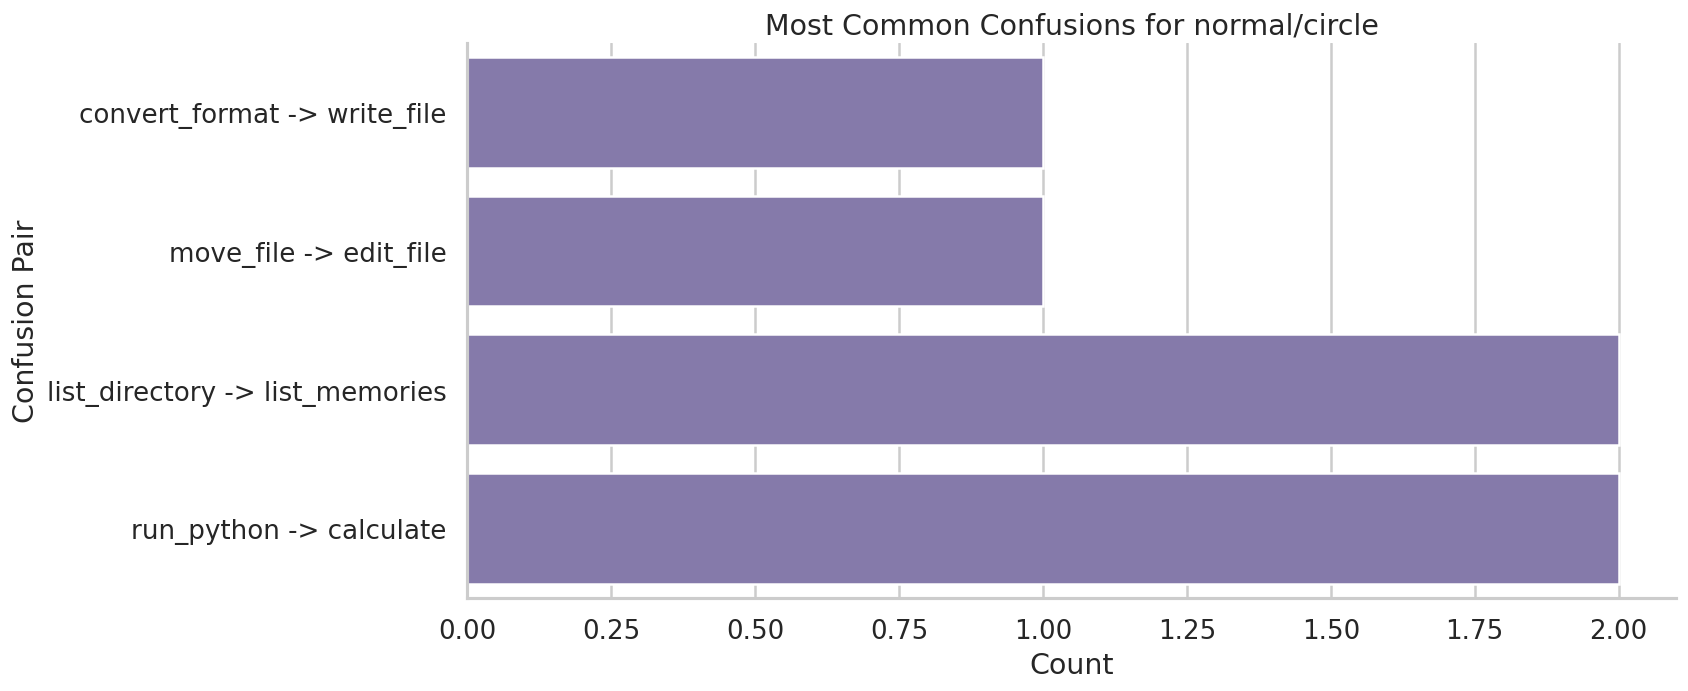

In [16]:
FIGURES['best_overall_confusion'], _ = plot_confusion_matrix(
    ok_results_df,
    adapter_id=best_overall_adapter,
    top_n_tools=12,
)
FIGURES['best_overall_common_confusions'], _ = plot_common_confusions(
    ok_results_df,
    adapter_id=best_overall_adapter,
    top_n=15,
)

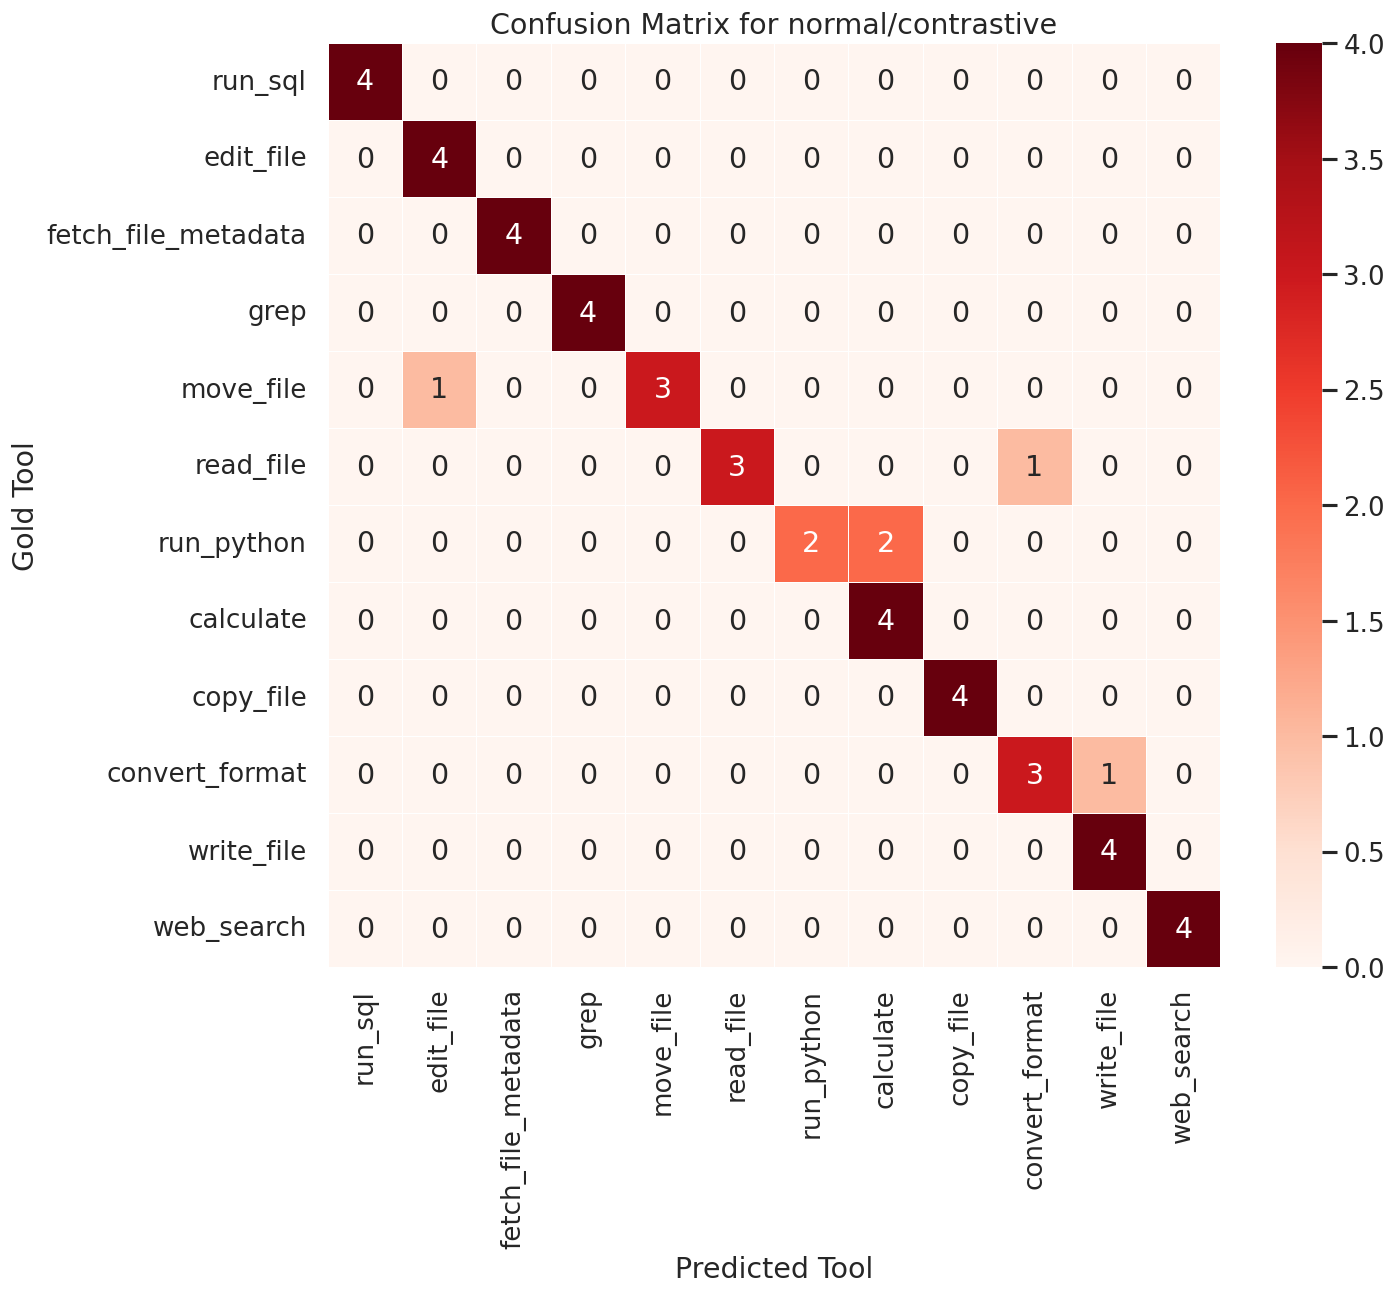

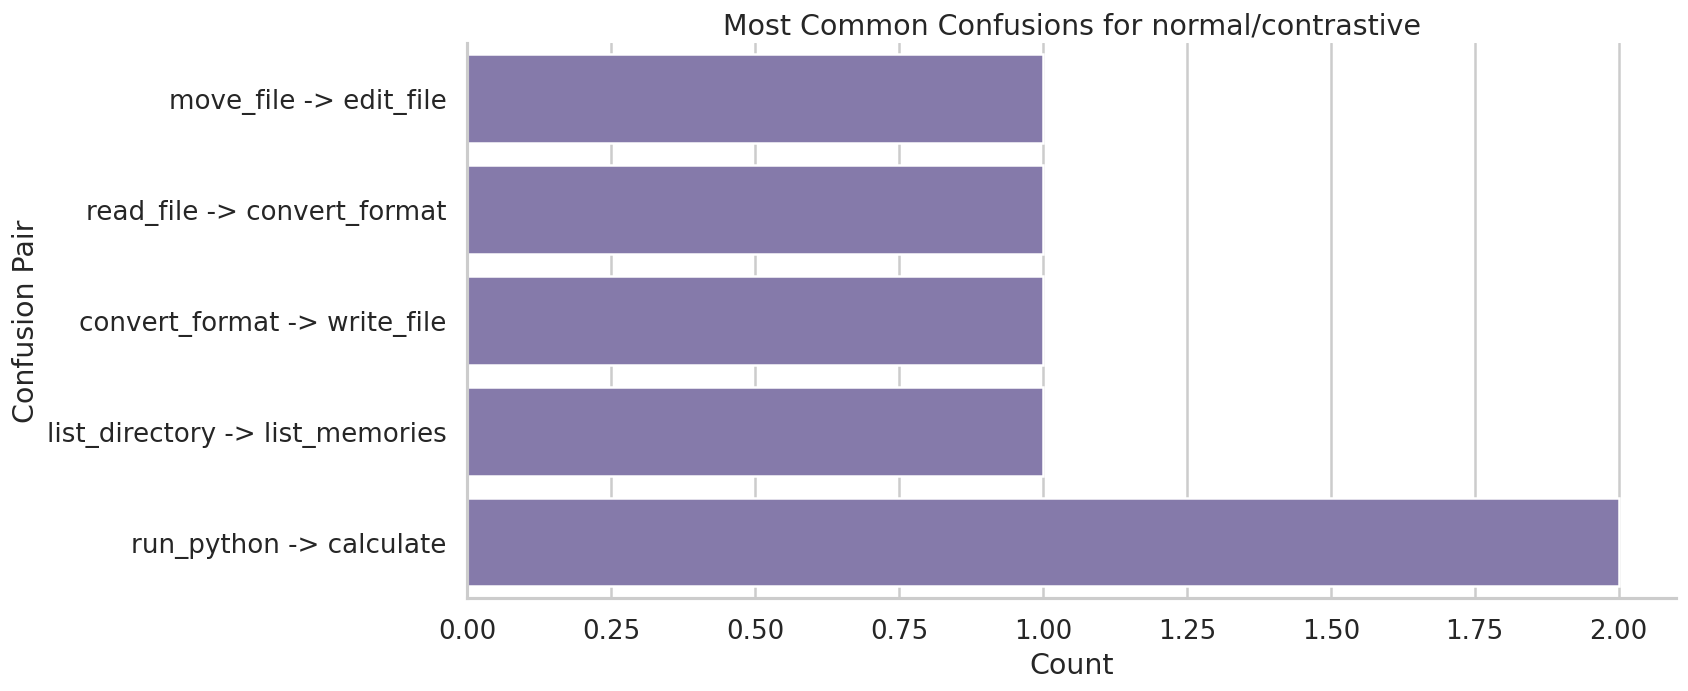

In [17]:
FIGURES['best_embedding_confusion'], _ = plot_confusion_matrix(
    ok_results_df,
    adapter_id=best_embedding_adapter,
    top_n_tools=12,
)
FIGURES['best_embedding_common_confusions'], _ = plot_common_confusions(
    ok_results_df,
    adapter_id=best_embedding_adapter,
    top_n=15,
)

In [18]:
saved_paths = {}
for name, fig in FIGURES.items():
    saved_paths[name] = save_figure(fig, FIGURES_DIR, name)

saved_paths

{'leaderboard_triptych': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/leaderboard_triptych.png'),
 'top1_leaderboard': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/top1_leaderboard.png'),
 'mrr_leaderboard': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/mrr_leaderboard.png'),
 'accuracy_latency_tradeoff': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/accuracy_latency_tradeoff.png'),
 'accuracy_token_tradeoff': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/accuracy_token_tradeoff.png'),
 'cost_accuracy_tradeoff': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/cost_accuracy_tradeoff.png'),
 'provider_top1_boxplot': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/provider_top1_boxplot.png'),
 'provider_mrr_boxplot': PosixPath('/scratch4/home/akrik/NTILC/analysis/figures/oss-full-benchmark/provider